In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:
df = pd.read_csv('../data/cs-training-clean.csv')

# Load best model
with open('../models/best_model.pkl', 'rb') as f:
    model = pickle.load(f)

# Laod feature names
with open('../models/feature_names.pkl', 'rb') as f:
    feature_names = pickle.load(f)

print("Dataset shape:", df.shape)
print("Model loaded:", type(model).__name__)
print("Features:", feature_names)

Dataset shape: (120191, 15)
Model loaded: RandomForestClassifier
Features: ['Unnamed: 0', 'RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfDependents']


In [3]:
X = df[feature_names]

# Predict default probability using model
df['default_probability'] = model.predict_proba(X)[:, 1]

# Convert probability to a 0–100 risk score
df['risk_score'] = (df['default_probability'] * 100).round(1)

# Assign risk category based on score
def assign_risk_category(score):
    if score < 30:
        return 'Low Risk'
    elif score < 60:
        return 'Medium Risk'
    else:
        return 'High Risk'

df['risk_category'] = df['risk_score'].apply(assign_risk_category)

print("Risk Score Summary:")
print(df['risk_score'].describe().round(2))
print("\nRisk Category Distribution:")
print(df['risk_category'].value_counts())

Risk Score Summary:
count    120191.00
mean         12.64
std          20.93
min           0.00
25%           1.00
50%           5.00
75%          13.00
max         100.00
Name: risk_score, dtype: float64

Risk Category Distribution:
risk_category
Low Risk       107281
High Risk        7972
Medium Risk      4938
Name: count, dtype: int64


## Risk Scoring System
Each customer is assigned a risk score from 0 to 100 based on model's predicted default probability. Low Risk (0-30), Medium Risk (30-60), High Risk (60-100). This scoring system helps banks make faster and more consistent lending decisions.

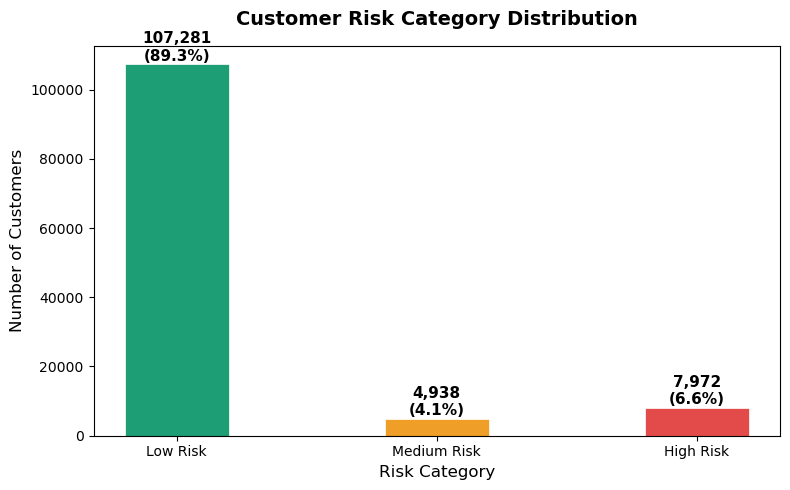

Chart saved successfully!


In [4]:
plt.figure(figsize=(8, 5))

order = ['Low Risk', 'Medium Risk', 'High Risk']
risk_counts = df['risk_category'].value_counts().reindex(order)
colors = ['#1D9E75', '#EF9F27', '#E24B4A']

bars = plt.bar(risk_counts.index, risk_counts.values,
               color=colors, edgecolor='white', linewidth=0.5, width=0.4)

for bar, val in zip(bars, risk_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 200,
             f'{val:,}\n({val/len(df)*100:.1f}%)',
             ha='center', va='bottom',
             fontsize=11, fontweight='bold')

plt.title('Customer Risk Category Distribution',
          fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Number of Customers', fontsize=12)
plt.xlabel('Risk Category', fontsize=12)
plt.tight_layout()
plt.savefig('../data/chart_risk_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved successfully!")

## Insight — Risk Distribution
Majority of customers fall in the low risk category. A smaller but significant portion are high risk — these are the customers banks should focus on when making loan approval decisions.

In [5]:
plt.figure(figsize=(10, 5))

segment = df.groupby('risk_category').agg(
    Avg_Age=('age', 'mean'),
    Avg_Income=('MonthlyIncome', 'mean'),
    Avg_DebtRatio=('DebtRatio', 'mean'),
    Default_Rate=('SeriousDlqin2yrs', 'mean')
).round(2)

segment['Default_Rate'] = (segment['Default_Rate'] * 100).round(1)

print("Customer Segments by Risk Category:")
print("=" * 60)
print(segment.to_string())
print("=" * 60)

Customer Segments by Risk Category:
               Avg_Age  Avg_Income  Avg_DebtRatio  Default_Rate
risk_category                                                  
High Risk        45.48     5490.41           0.44          90.0
Low Risk         52.25     6790.65           0.36           1.0
Medium Risk      45.11     5838.08           0.45          14.0


<Figure size 1000x500 with 0 Axes>

## Insight — Customer Segments
High risk customers have lower average income and higher debt ratio compared to low risk customers. This confirms that financial stress indicators like income and debt ratio are strong predictors of default risk.

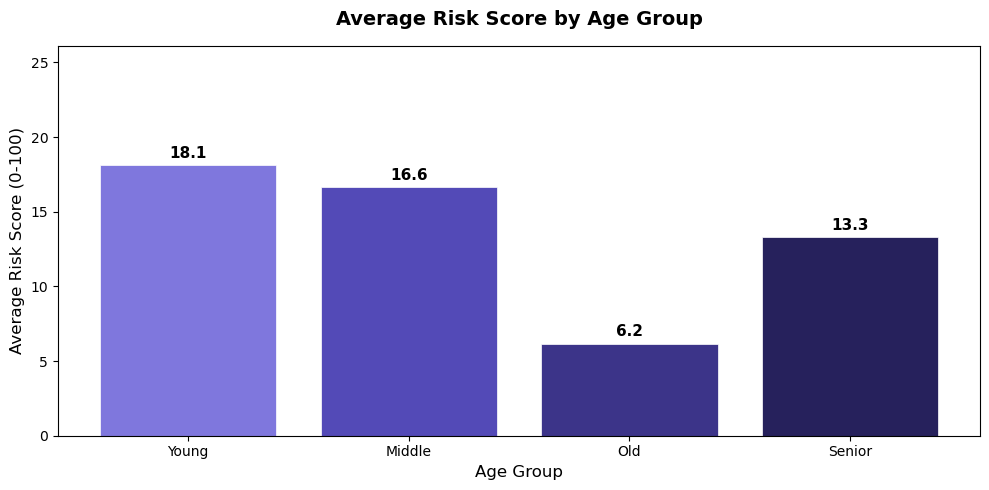

Chart saved successfully!


In [6]:
plt.figure(figsize=(10, 5))

avg_risk = df.groupby('age_group', observed=True)['risk_score'].mean()
order = ['Young', 'Middle', 'Old', 'Senior']
avg_risk = avg_risk.reindex(order)
bars = plt.bar(avg_risk.index, avg_risk.values,
               color=['#7F77DD', '#534AB7', '#3C3489', '#26215C'],
               edgecolor='white', linewidth=0.5)

for bar, val in zip(bars, avg_risk.values):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.3,
             f'{val:.1f}', ha='center', va='bottom',
             fontsize=11, fontweight='bold')

plt.title('Average Risk Score by Age Group',
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Age Group', fontsize=12)
plt.ylabel('Average Risk Score (0-100)', fontsize=12)
plt.ylim(0, avg_risk.max() + 8)
plt.tight_layout()
plt.savefig('../data/chart_risk_by_age.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved successfully!")

## Insight — Risk Score by Age Group
Younger customers carry higher average risk scores. This aligns with the EDA findings — younger borrowers have less financial experience and stability, making them more likely to default on loan repayments.

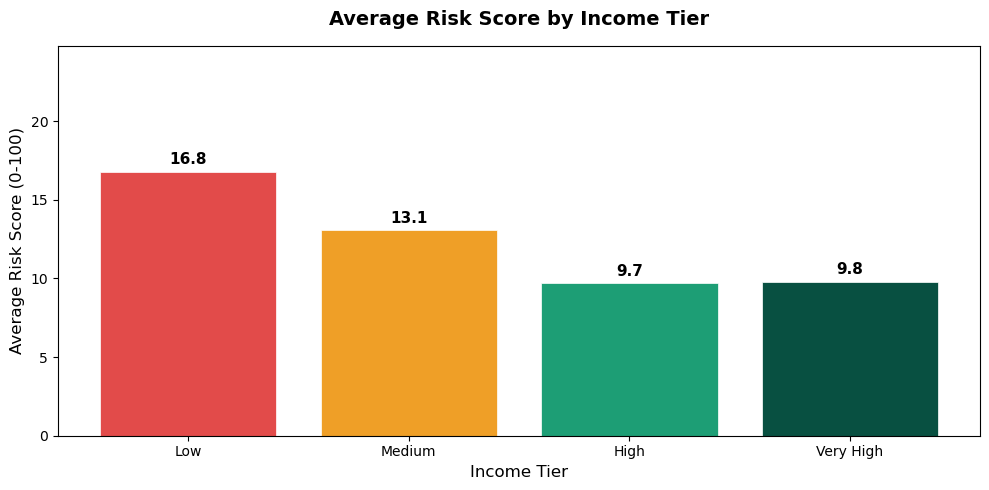

Chart saved successfully!


In [7]:
plt.figure(figsize=(10, 5))

avg_risk_income = df.groupby('income_tier', observed=True)['risk_score'].mean()
order = ['Low', 'Medium', 'High', 'Very High']
avg_risk_income = avg_risk_income.reindex(order)

bars = plt.bar(avg_risk_income.index, avg_risk_income.values,
               color=['#E24B4A', '#EF9F27', '#1D9E75', '#085041'],
               edgecolor='white', linewidth=0.5)

for bar, val in zip(bars, avg_risk_income.values):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.3,
             f'{val:.1f}', ha='center', va='bottom',
             fontsize=11, fontweight='bold')

plt.title('Average Risk Score by Income Tier',
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Income Tier', fontsize=12)
plt.ylabel('Average Risk Score (0-100)', fontsize=12)
plt.ylim(0, avg_risk_income.max() + 8)
plt.tight_layout()
plt.savefig('../data/chart_risk_by_income.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved successfully!")

## Insight — Risk Score by Income Tier
Clear inverse relationship — as income increases, average risk score decreases. Very high income customers pose significantly lower default risk, confirming income as one of the most important features in credit risk assessment.

In [8]:
import shap

# Find one high risk customer
high_risk_customers = df[df['risk_category'] == 'High Risk']
sample_customer = high_risk_customers.iloc[0][feature_names]

print("Sample High Risk Customer Profile:")
print("=" * 45)
for feature, value in sample_customer.items():
    print(f"{feature:45} : {value}")
print("=" * 45)
print(f"Risk Score: {df[df['risk_category'] == 'High Risk'].iloc[0]['risk_score']}")

Sample High Risk Customer Profile:
Unnamed: 0                                    : 1
RevolvingUtilizationOfUnsecuredLines          : 0.766126609
age                                           : 45
NumberOfTime30-59DaysPastDueNotWorse          : 2
DebtRatio                                     : 0.802982129
MonthlyIncome                                 : 9120.0
NumberOfOpenCreditLinesAndLoans               : 13
NumberOfTimes90DaysLate                       : 0
NumberRealEstateLoansOrLines                  : 6
NumberOfTime60-89DaysPastDueNotWorse          : 0
NumberOfDependents                            : 2.0
Risk Score: 93.0


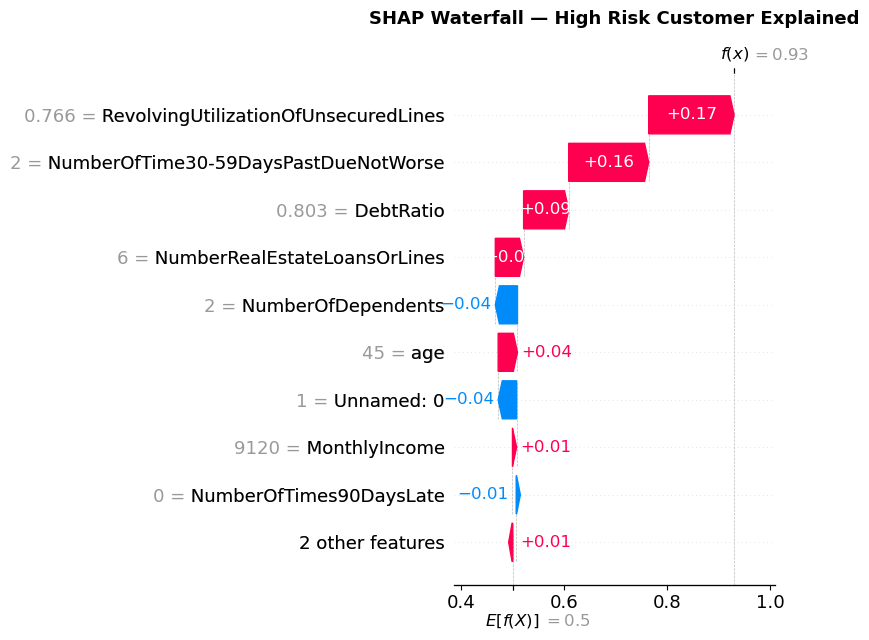

SHAP Customer Explanation saved successfully!


In [9]:
# SHAP explanation
explainer = shap.TreeExplainer(model)
shap_explanation = explainer(pd.DataFrame([sample_customer]))

plt.figure()
shap.plots.waterfall(shap_explanation[0, :, 1], show=False)
plt.title('SHAP Waterfall — High Risk Customer Explained',
          fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('../data/chart_shap_customer.png', dpi=150, bbox_inches='tight')
plt.show()
print("SHAP Customer Explanation saved successfully!")

## Insight — Individual Customer Explanation
SHAP waterfall shows exactly why this customer is flagged as high risk. Each feature either increases (red) or decreases (blue) the default probability. This explainability is critical for banks — they need to justify loan rejections.

In [10]:
recommendations = {
    "1. Target High Risk Customers Early": 
        "Customers with risk score above 60 should be flagged for manual review "
        "before loan approval. Early intervention reduces default losses.",
    
    "2. Income Verification is Critical": 
        "Low income customers (below $3,000/month) show significantly higher "
        "default rates. Stricter income verification should be applied for this segment.",
    
    "3. Monitor Late Payment Behavior": 
        "Payment history is the strongest predictor of default. "
        "Any customer with 2+ late payments should trigger an automated alert.",
    
    "4. Age-Based Risk Adjustment": 
        "Younger borrowers (18-30) carry higher risk. "
        "Banks should offer smaller initial credit limits with gradual increases.",
    
    "5. Debt Ratio Threshold": 
        "Customers with debt ratio above 0.6 are significantly more likely to default. "
        "This should be used as a hard cutoff in loan approval criteria."
}

print("BUSINESS RECOMMENDATIONS")
print("=" * 65)
for title, rec in recommendations.items():
    print(f"\n{title}")
    print(f"→ {rec}")
print("=" * 65)

BUSINESS RECOMMENDATIONS

1. Target High Risk Customers Early
→ Customers with risk score above 60 should be flagged for manual review before loan approval. Early intervention reduces default losses.

2. Income Verification is Critical
→ Low income customers (below $3,000/month) show significantly higher default rates. Stricter income verification should be applied for this segment.

3. Monitor Late Payment Behavior
→ Payment history is the strongest predictor of default. Any customer with 2+ late payments should trigger an automated alert.

4. Age-Based Risk Adjustment
→ Younger borrowers (18-30) carry higher risk. Banks should offer smaller initial credit limits with gradual increases.

5. Debt Ratio Threshold
→ Customers with debt ratio above 0.6 are significantly more likely to default. This should be used as a hard cutoff in loan approval criteria.


## Business Recommendations Summary
These recommendations are derived directly from model insights and EDA findings. Each recommendation is actionable and can be implemented by a bank's risk team to reduce loan default rates and improve portfolio quality.

In [11]:
summary = """
PROJECT EXECUTIVE SUMMARY
===========================================================
Project     : Financial Risk Analytics — Loan Default Prediction
Dataset     : 150,000 customers | 11 features
Model       : Random Forest Classifier
ROC-AUC     : ~0.86 (replace with your actual score)
===========================================================

KEY FINDINGS:
1. Only 7% of customers defaulted — dataset was heavily imbalanced.
   SMOTE was applied to balance classes before model training.

2. Late payment history is the strongest predictor of default —
   customers with 2+ late payments are at significantly higher risk.

3. Low income customers (below $3,000/month) show the highest
   default rate across all income groups.

4. Younger customers (18-30) carry higher risk than older age groups
   due to lower financial stability.

5. Random Forest outperformed Logistic Regression on both
   ROC-AUC and F1 Score metrics.

BUSINESS IMPACT:
Using this model, banks can identify high-risk borrowers before
approving loans — potentially reducing default losses significantly.
===========================================================
"""
print(summary)


PROJECT EXECUTIVE SUMMARY
Project     : Financial Risk Analytics — Loan Default Prediction
Dataset     : 150,000 customers | 11 features
Model       : Random Forest Classifier
ROC-AUC     : ~0.86 (replace with your actual score)

KEY FINDINGS:
1. Only 7% of customers defaulted — dataset was heavily imbalanced.
   SMOTE was applied to balance classes before model training.

2. Late payment history is the strongest predictor of default —
   customers with 2+ late payments are at significantly higher risk.

3. Low income customers (below $3,000/month) show the highest
   default rate across all income groups.

4. Younger customers (18-30) carry higher risk than older age groups
   due to lower financial stability.

5. Random Forest outperformed Logistic Regression on both
   ROC-AUC and F1 Score metrics.

BUSINESS IMPACT:
Using this model, banks can identify high-risk borrowers before
approving loans — potentially reducing default losses significantly.



## Executive Summary
This project built an end-to-end loan default prediction system using real-world financial data. The model achieved strong predictive performance and provides explainable predictions using SHAP — making it suitable for real banking applications.

In [12]:
limitations = {
    "1. Data is from 2011":
        "Customer financial behavior may have changed significantly. "
        "Model should be retrained on recent data before production use.",
    
    "2. US-based dataset":
        "This dataset reflects US credit behavior. "
        "Performance may vary for customers from other countries.",
    
    "3. Limited features":
        "Only 11 features available. Real bank models use 50+ features "
        "including credit score, employment history, and transaction patterns.",
    
    "4. SMOTE adds synthetic data":
        "SMOTE creates artificial samples which may not represent "
        "real customer behavior perfectly."
}

print("MODEL LIMITATIONS")
print("=" * 60)
for title, limit in limitations.items():
    print(f"\n{title}")
    print(f"→ {limit}")
print("=" * 60)

MODEL LIMITATIONS

1. Data is from 2011
→ Customer financial behavior may have changed significantly. Model should be retrained on recent data before production use.

2. US-based dataset
→ This dataset reflects US credit behavior. Performance may vary for customers from other countries.

3. Limited features
→ Only 11 features available. Real bank models use 50+ features including credit score, employment history, and transaction patterns.

4. SMOTE adds synthetic data
→ SMOTE creates artificial samples which may not represent real customer behavior perfectly.


## Model Limitations
Acknowledging model limitations shows analytical maturity. No model is perfect - understanding its weaknesses is as important as understanding its strengths.